
# 02425 Diffusion and stochastich differential equations


## WEEK 5: The ito integral

In [884]:
import numpy as np
import random
from numpy import random
from matplotlib import pyplot as plt
import scipy.stats as stats


### Exercise 1

In [885]:
T = 2*np.pi
dt = 0.001
x = 0
f = lambda x, t: 0.5 * x
g = lambda x, t: 0.1 * x

def eulersum(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x
    for i in range(1, N):
        dW1 = np.random.normal(0, np.sqrt(dt))
        X[i] = X[i-1] + np.cos(t[i-1])**2 * dt
    return t, X


t, X = eulersum(f, g, T, dt, x)

In [886]:

closedform = 1/2 * T + 1/4 * np.sin(2*T)

print(X[-1]-closedform)

-0.000592653589789105


### Exercise 2

In [887]:
T = 100
dt = 0.5
x = 0
partition = np.linspace(0, T, int(T/dt))

def Brownian(partition):

        BrownianMotion = np.array([])

        for i in range(len(partition)):

            if partition[i] == 0:
                BrownianMotion = np.append(BrownianMotion, 0)
            if partition[i] != 0:
                BrownianMotion = np.append(BrownianMotion, random.normal(loc=BrownianMotion[-1], scale=np.sqrt(partition[i]-partition[i-1])))

        return BrownianMotion

Bt = Brownian(partition)

def eulerbrownian(T,dt,x):



    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x


    for i in range(1, N):
        X[i] = X[i-1] + Bt[i-1] * (Bt[i] - Bt[i-1])
    return t, X


t, X = eulerbrownian(T, dt, x)

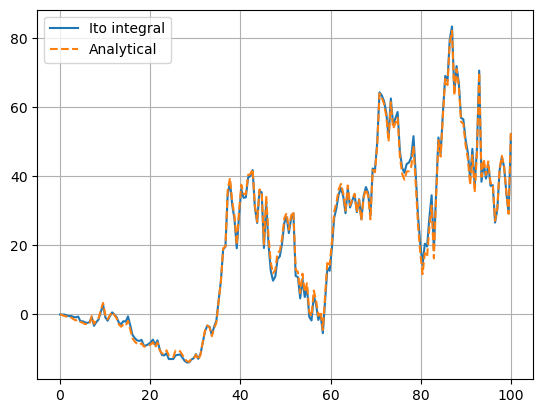

In [888]:

plt.plot(partition, X, label="Ito integral")

analytical = 0.5 * (Bt**2 - partition)
plt.plot(partition, analytical, "--", label="Analytical")

plt.legend()
plt.grid()
plt.show()

### Exercise 3

In [889]:
T = 10
dt = 0.001
x = 0
f = lambda t: 0.5 * t
g = lambda t: 0.1 * t

def eulersumR(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    for i in range(1, N):
        X[i] = X[i-1] + f(t[i]) * (g(t[i])-g(t[i-1])) 
    return t, X

t, XR = eulersumR(f, g, T, dt, x)

In [890]:
T = 10
dt = 0.001
x = 0
f = lambda t: 0.5 * t
g = lambda t: 0.1 * t

def eulersumS(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    for i in range(1, N):
        X[i] = X[i-1] + 1/2 * (f(t[i-1]) + f(t[i])) * (g(t[i])-g(t[i-1])) 
    return t, X

t, XS = eulersumS(f, g, T, dt, x)

In [891]:
T = 10
dt = 0.001
x = 0
f = lambda t: 0.5 * t
g = lambda t: 0.1 * t

def eulersumL(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x
    for i in range(1, N):
        X[i] = X[i-1] + f(t[i-1]) * (g(t[i])-g(t[i-1])) 
    return t, X

t, XL = eulersumL(f, g, T, dt, x)

In [892]:
XR = np.zeros(len(Bt))
XS = np.zeros(len(Bt))
XL = np.zeros(len(Bt))

for i in range(1, len(Bt)):

    dB = Bt[i] - Bt[i-1]

    XR[i] = XR[i-1] + Bt[i] * dB

    XS[i] = XS[i-1] + 0.5*(Bt[i-1] + Bt[i])*dB

    XL[i] = XL[i-1] + Bt[i-1]*dB

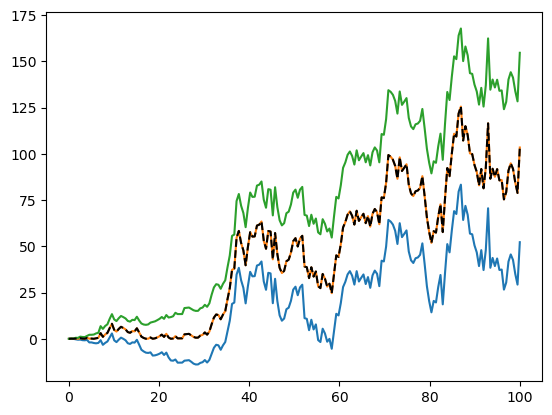

In [893]:
plt.plot(partition, XL, label="Ito / left")
plt.plot(partition, XS, label="Stratonovich")
plt.plot(partition, XR, label="Right")
plt.plot(partition, 0.5*Bt**2, label=r"$\frac12 B_t^2$", color="black", linestyle="--")

### Exercise 4

### Exercise 4

We are interested in finding the mean and variance of

$$
I_t=\int_0^t B_s\,dB_s
=
\frac{1}{2}B_t^2-\frac{1}{2}t.
$$

Since

$$
B_t \sim N(0,t),
$$

we know that

$$
E[B_t^2]=t.
$$

Therefore the mean is

$$
E[I_t]
=
E\left[\frac{1}{2}B_t^2-\frac{1}{2}t\right]
=
\frac{1}{2}E[B_t^2]-\frac{1}{2}t
=
\frac{1}{2}t-\frac{1}{2}t
=
0.
$$

Now we calculate the variance. Since subtracting a constant does not change the variance,

$$
V[I_t]
=
V\left[\frac{1}{2}B_t^2-\frac{1}{2}t\right]
=
\frac{1}{4}V[B_t^2].
$$

For a Gaussian variable $B_t\sim N(0,t)$ we have

$$
E[B_t^4]=3t^2.
$$

Therefore

$$
V[B_t^2]
=
E[B_t^4]-E[B_t^2]^2
=
3t^2-t^2
=
2t^2.
$$

Thus

$$
V[I_t]
=
\frac{1}{4}2t^2
=
\frac{t^2}{2}.
$$

We have therefore found

$$
E[I_t]=0,
\qquad
V[I_t]=\frac{t^2}{2}.
$$

The mean is zero, which agrees with the martingale property of the Itō integral.

Furthermore, by the Itō isometry,

$$
E\left[\left(\int_0^t B_s\,dB_s\right)^2\right]
=
\int_0^t E[B_s^2]\,ds
=
\int_0^t s\,ds
=
\frac{t^2}{2}.
$$

Since $E[I_t]=0$, this is also the variance, which agrees with the result above.

### Exercise 5

In [894]:
def Brownian(partition):

    BrownianMotion = np.array([])

    for i in range(len(partition)):

        if partition[i] == 0:
            BrownianMotion = np.append(BrownianMotion, 0)
        if partition[i] != 0:
            BrownianMotion = np.append(BrownianMotion, random.normal(loc=BrownianMotion[-1], scale=np.sqrt(partition[i]-partition[i-1])))

    return BrownianMotion

T = 100
dt = 0.01

partition = np.linspace(0, T, int(T/dt))

In [895]:
lmda = 1/2
gamma = 1
chsi = 2

T = 100
dt = 0.01
x = chsi



f = lambda x: lmda * (chsi - x)
g = lambda x: gamma*np.sqrt(np.abs(x))

Bt = Brownian(partition)

def eulersumL(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x


    for i in range(1, N):

        X[i] = X[i-1] + f(X[i-1])* dt + g(X[i-1]) * (Bt[i] - Bt[i-1])
    return t, X

t, XL = eulersumL(f, g, T, dt, x)
XL

array([2.        , 1.99580879, 2.06196782, ..., 1.12791283, 1.2165118 ,
       1.14761928])

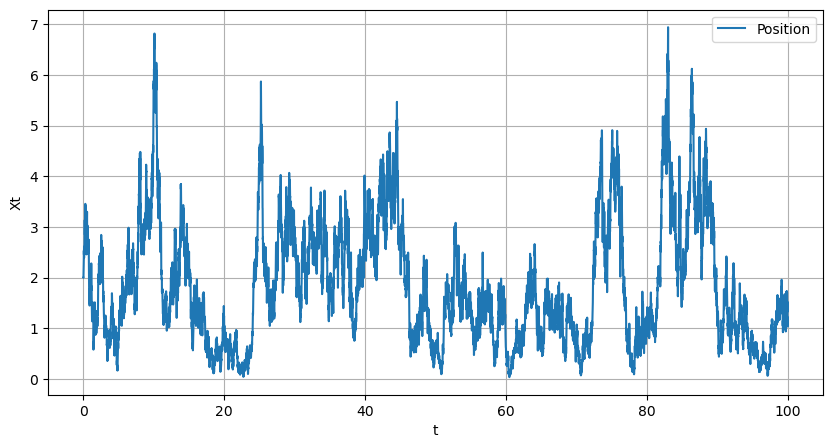

In [896]:
plt.figure(figsize=(10, 5))

plt.plot(t, XL, label="Position")

plt.xlabel("t")
plt.ylabel("Xt")
plt.legend()
plt.grid()

plt.show()

### Exercise 6

In [897]:
lmda = 1/2
gamma = 1
chsi = 2

T = 100
dt = 0.01
x = chsi

dt = dt*10

Bt = Bt[::10]



f = lambda x: lmda * (chsi - x)
g = lambda x: gamma*np.sqrt(np.abs(x))


def eulersumL(f,g,T,dt,x):
    N = int(T/dt)
    t = np.linspace(0, T, N)
    X = np.zeros(N)
    X[0] = x


    for i in range(1, N):

        X[i] = X[i-1] + f(X[i-1])* dt + g(X[i-1]) * (Bt[i] - Bt[i-1])
    return t, X

t, XL = eulersumL(f, g, T, dt, x)

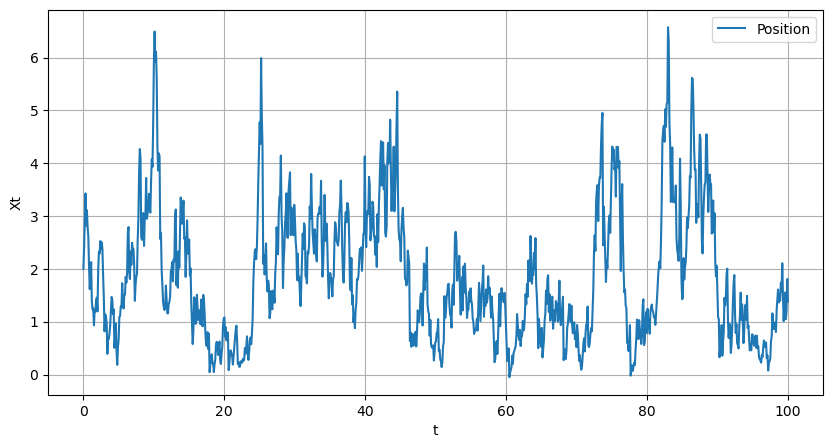

In [898]:
plt.figure(figsize=(10, 5))

plt.plot(t, XL, label="Position")

plt.xlabel("t")
plt.ylabel("Xt")
plt.legend()
plt.grid()

plt.show()

### Exercise 7

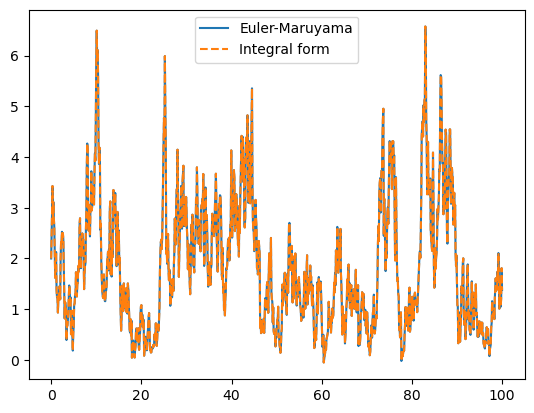

In [899]:
drift = np.zeros(len(XL))
ito = np.zeros(len(XL))

for i in range(1, len(XL)):
    drift[i] = drift[i-1] + lmda * (chsi - XL[i-1]) * dt
    ito[i] = ito[i-1] + gamma * np.sqrt(abs(XL[i-1])) * (Bt[i] - Bt[i-1])

X_integral = XL[0] + drift + ito

plt.plot(t, XL, label="Euler-Maruyama")
plt.plot(t, X_integral, "--", label="Integral form")
plt.legend()
plt.show()

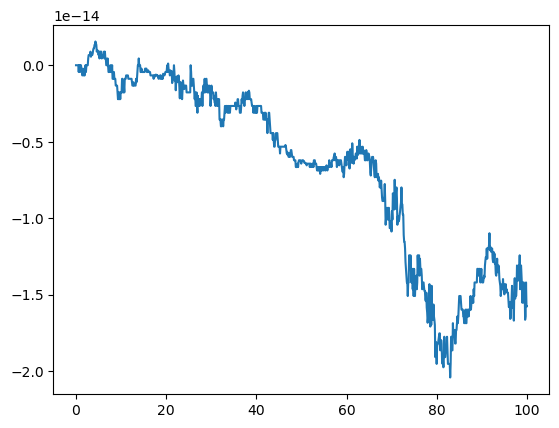

In [900]:
plt.plot(t, XL-X_integral, label="Ito / left")


### Exercise 8

We consider the Cox-Ingersoll-Ross process

$$
dX_t
=
\lambda(\xi-X_t)\,dt
+
\gamma\sqrt{X_t}\,dB_t.
$$

Using Euler-Maruyama,

$$
X_{n+1}
=
X_n
+
\lambda(\xi-X_n)\Delta t
+
\gamma\sqrt{X_n}\Delta B_n.
$$

Let

$$
m_n=E[X_n].
$$

Taking expectations gives

$$
m_{n+1}
=
m_n+\lambda(\xi-m_n)\Delta t,
$$

since

$$
E[\Delta B_n]=0.
$$

Therefore,

$$
\frac{m_{n+1}-m_n}{\Delta t}
=
\lambda(\xi-m_n).
$$

Letting $\Delta t\to0$ gives

$$
\frac{dm}{dt}
=
\lambda(\xi-m).
$$

For the variance, let

$$
v_n=V[X_n].
$$

We write

$$
X_{n+1}
=
(1-\lambda\Delta t)X_n
+
\lambda\xi\Delta t
+
\gamma\sqrt{X_n}\Delta B_n.
$$

Since $\Delta B_n$ is independent of $X_n$ and

$$
V[\Delta B_n]=\Delta t,
$$

we get

$$
v_{n+1}
=
(1-\lambda\Delta t)^2v_n
+
\gamma^2m_n\Delta t.
$$

Thus,

$$
\frac{v_{n+1}-v_n}{\Delta t}
=
(-2\lambda+\lambda^2\Delta t)v_n
+
\gamma^2m_n.
$$

Letting $\Delta t\to0$ gives

$$
\frac{dv}{dt}
=
-2\lambda v+\gamma^2m.
$$

For stationarity,

$$
\frac{dm}{dt}=0,
$$

so

$$
0=\lambda(\xi-m),
$$

and therefore

$$
m_{\infty}=\xi.
$$

Similarly,

$$
\frac{dv}{dt}=0,
$$

so

$$
0=-2\lambda v_{\infty}+\gamma^2\xi.
$$

Therefore,

$$
v_{\infty}
=
\frac{\gamma^2\xi}{2\lambda}.
$$

To find the stationary autocovariance, we use

$$
E[X_{t+\tau}\mid X_t]
=
\xi+(X_t-\xi)e^{-\lambda\tau}.
$$


Hence,

$$
\operatorname{Cov}(X_t,X_{t+\tau})
=
E\left[
(X_t-\xi)(X_{t+\tau}-\xi)
\right].
$$

Using conditional expectation,

$$
E[X_{t+\tau}-\xi\mid X_t]
=
(X_t-\xi)e^{-\lambda\tau}.
$$

Therefore,

$$
\operatorname{Cov}(X_t,X_{t+\tau})
=
e^{-\lambda\tau}
E[(X_t-\xi)^2].
$$

In stationarity,

$$
E[(X_t-\xi)^2]
=
v_{\infty}
=
\frac{\gamma^2\xi}{2\lambda}.
$$

Thus the stationary autocovariance function is

$$
\operatorname{Cov}(X_t,X_{t+\tau})
=
\frac{\gamma^2\xi}{2\lambda}
e^{-\lambda\tau}.
$$

Therefore, the stationary mean, variance and autocovariance are

$$
E[X_t]=\xi,
$$

$$
V[X_t]
=
\frac{\gamma^2\xi}{2\lambda},
$$

and

$$
\operatorname{Cov}(X_t,X_{t+\tau})
=
\frac{\gamma^2\xi}{2\lambda}
e^{-\lambda\tau}.
$$